# Week 7 — Function Approximation — Additional Examples

**Programming and Numerical Methods for Economics (ECNM10115)** · The University of Edinburgh

Companion examples to the [Week 7 main notebook](week07_funcapprox.ipynb).

> **How to work through this notebook:** run every cell in order (`Shift+Enter`). When you reach a result, pause and predict it before running — that habit is what turns reading into learning. Experiment: change parameters, break things, re-run.


## <center>Programing and Numerical Methods in Economics
### <center>Function Approximation

In [32]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

In [33]:
def vandermonde(X):
    n = len(X)
    V = np.array([[xi**s for s in range(n)] for xi in X])
    return V

In [34]:
def lagrange(X, y):
    V = vandermonde(X)
    return np.linalg.solve(V, y)

In [35]:
def evaluate(a, x):
    xi = 1
    v = 0.0
    for ai in a:
        v += ai * xi 
        xi *= x
    return v

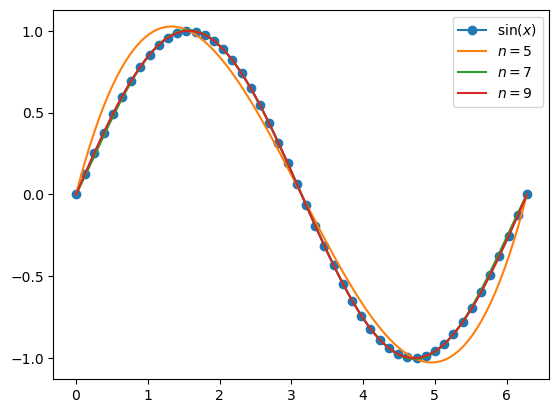

In [36]:
# Plotting
plt.figure()
x = np.linspace(0, 2 * np.pi, 50)
plt.plot(x, np.sin(x), marker='o', label=r'$\sin(x)$')

for n in (5, 7, 9):
    X = np.linspace(0, 2 * np.pi, n)
    y = np.sin(X)
    a = lagrange(X, y)
    x_fine = np.linspace(0, 2 * np.pi, 100)
    plt.plot(x_fine, [evaluate(a, x_val) for x_val in x_fine], label=f"$n = {n}$")

plt.legend()
plt.show()

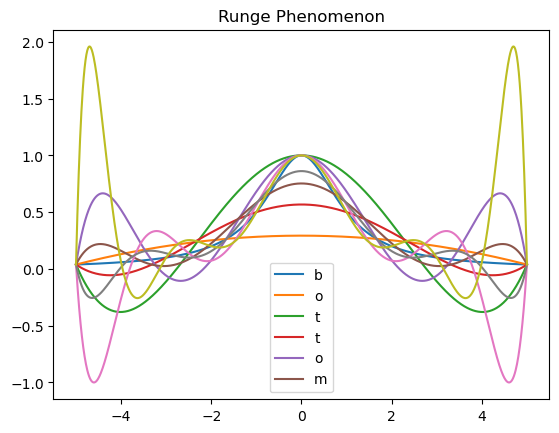

In [37]:
xg = np.linspace(-5, 5, 1000)
f = lambda x: 1 / (1 + x**2)
plt.figure()
# plt.plot(xg, f(xg), label=r"$f(x) = 1/(1 + x^2)$", title='Runge Phenomenon')
plt.plot(xg, f(xg),label=r'$\sin(x)$')
plt.title('Runge Phenomenon')
for n in range(4, 12):
    X = np.linspace(-5, 5, n)
    y = f(X)
    a = lagrange(X, y)
    plt.plot(xg, [evaluate(a, x_val) for x_val in xg], label=f"$n = {n}$")

plt.legend('bottom')
plt.show()

C:\Users\jzurita\AppData\Local\Temp\ipykernel_29536\2212560740.py:2: RuntimeWarning: invalid value encountered in arccos
  return np.cos(2*n * np.arccos(x))


ValueError: x and y must have same first dimension, but have shapes (100,) and (20,)

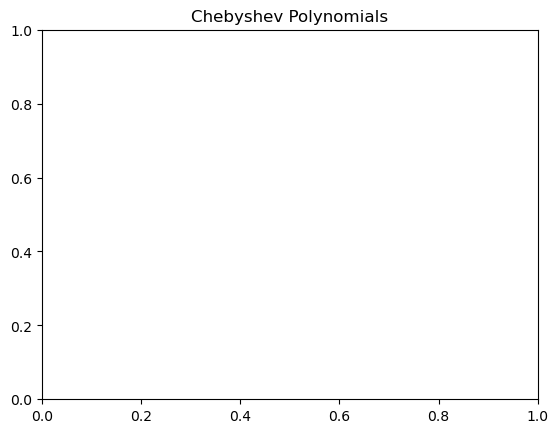

In [52]:
def T(n, x):
    return np.cos(n * np.arccos(x))

plt.title("Chebyshev Polynomials")

for i in range(5):
    plt.plot(np.linspace(-1, 1, 100), T(i, x), label=f"$T_{i}(x)$")

plt.show()

In [44]:
a, b, f = -5, 5, lambda x: 1 / (1 + x**2)
n = 30
m = n + 1
z = [-np.cos((2 * k - 1) / (2 * m) * np.pi) for k in range(1, m + 1)]  # interpolation points
x = (np.array(z) + 1) * (b - a) / 2 + a
y = f(x)

In [46]:

c = []
for i in range(m + 1):
    numerator = sum(y[k] * T(i, z[k]) for k in range(m))
    denominator = sum(T(i, z[k])**2 for k in range(m))
    c.append(numerator / denominator)


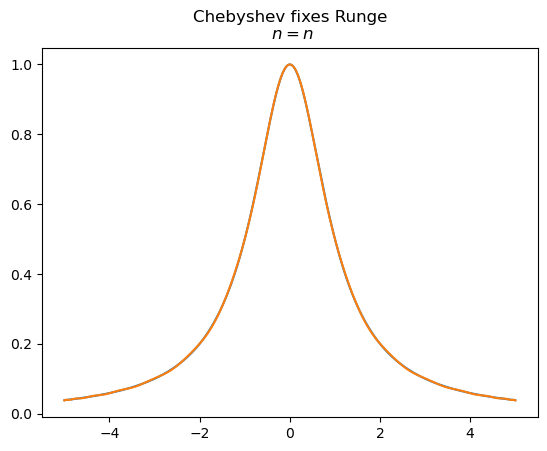

In [48]:

def f_hat(x):
    return sum(ci * T(i, 2 * (x - a) / (b - a) - 1) for ci, i in zip(c, range(n + 1)))

xg = np.linspace(-5, 5, 1000)
# plt.figure(figsize=(8, 6), title="Chebyshev fixes Runge\n $n = {n}$")
# plt.figsize(8, 6)
plt.title("Chebyshev fixes Runge\n $n = {n}$")
plt.plot(xg, f(xg), label=r"$f(x) = 1/(1+x^2)$")
plt.plot(xg, f_hat(xg), label=r"$\hat f(x)$")
plt.show()


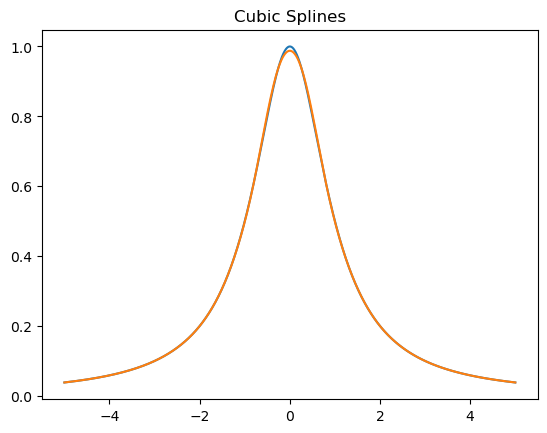

In [50]:
from scipy.interpolate import CubicSpline

f = lambda x: 1 / (1 + x**2)
a, b, n = -5, 5, 20

x = np.linspace(a, b, n)
y = f(x)
f_hat = CubicSpline(x, y)

# Plot the results
plt.title("Cubic Splines")
xg = np.linspace(a, b, 1000)
plt.plot(xg, f(xg), label=r"$f(x) = 1/(1+x^2)$")
plt.plot(xg, f_hat(xg), label=f"$\\hat{{f}}: n = {n}$")
plt.show()

*Back to the [course page](../index.qmd).*